<a href="https://colab.research.google.com/github/Faiva-404/PCVK_Ganjil_2026/blob/main/Weekk7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Faiva Puspa Sahara (06)
> MODUL 6 – Filter Spasial Low Pass Filter, High Pass Filter, Point
Detection, Line Detection, Edge Detection

D. PRAKTIKUM FILTER

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from PIL import Image as im
import matplotlib.pyplot as plt
import numpy as np
import math

In [4]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Jika citra memiliki channel warna (3D), ubah ke grayscale atau ambil 1 channel
    if len(image.shape) == 3:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Tambahkan padding pada citra
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_image = image.copy()

    img_h, img_w = padded_image.shape
    k_h, k_w = kernel.shape

    # Hitung dimensi output
    out_h = int((img_h - k_h) / stride) + 1
    out_w = int((img_w - k_w) / stride) + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    # Proses Konvolusi
    for y in range(0, out_h):
        for x in range(0, out_w):
            # Ambil region/jendela citra sesuai ukuran kernel
            y_start = y * stride
            x_start = x * stride
            region = padded_image[y_start:y_start+k_h, x_start:x_start+k_w]

            # Hitung sum-product antara region dan kernel
            output[y, x] = np.sum(region * kernel)

    # Clip nilai piksel agar berada di rentang 0-255 dan ubah ke uint8
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

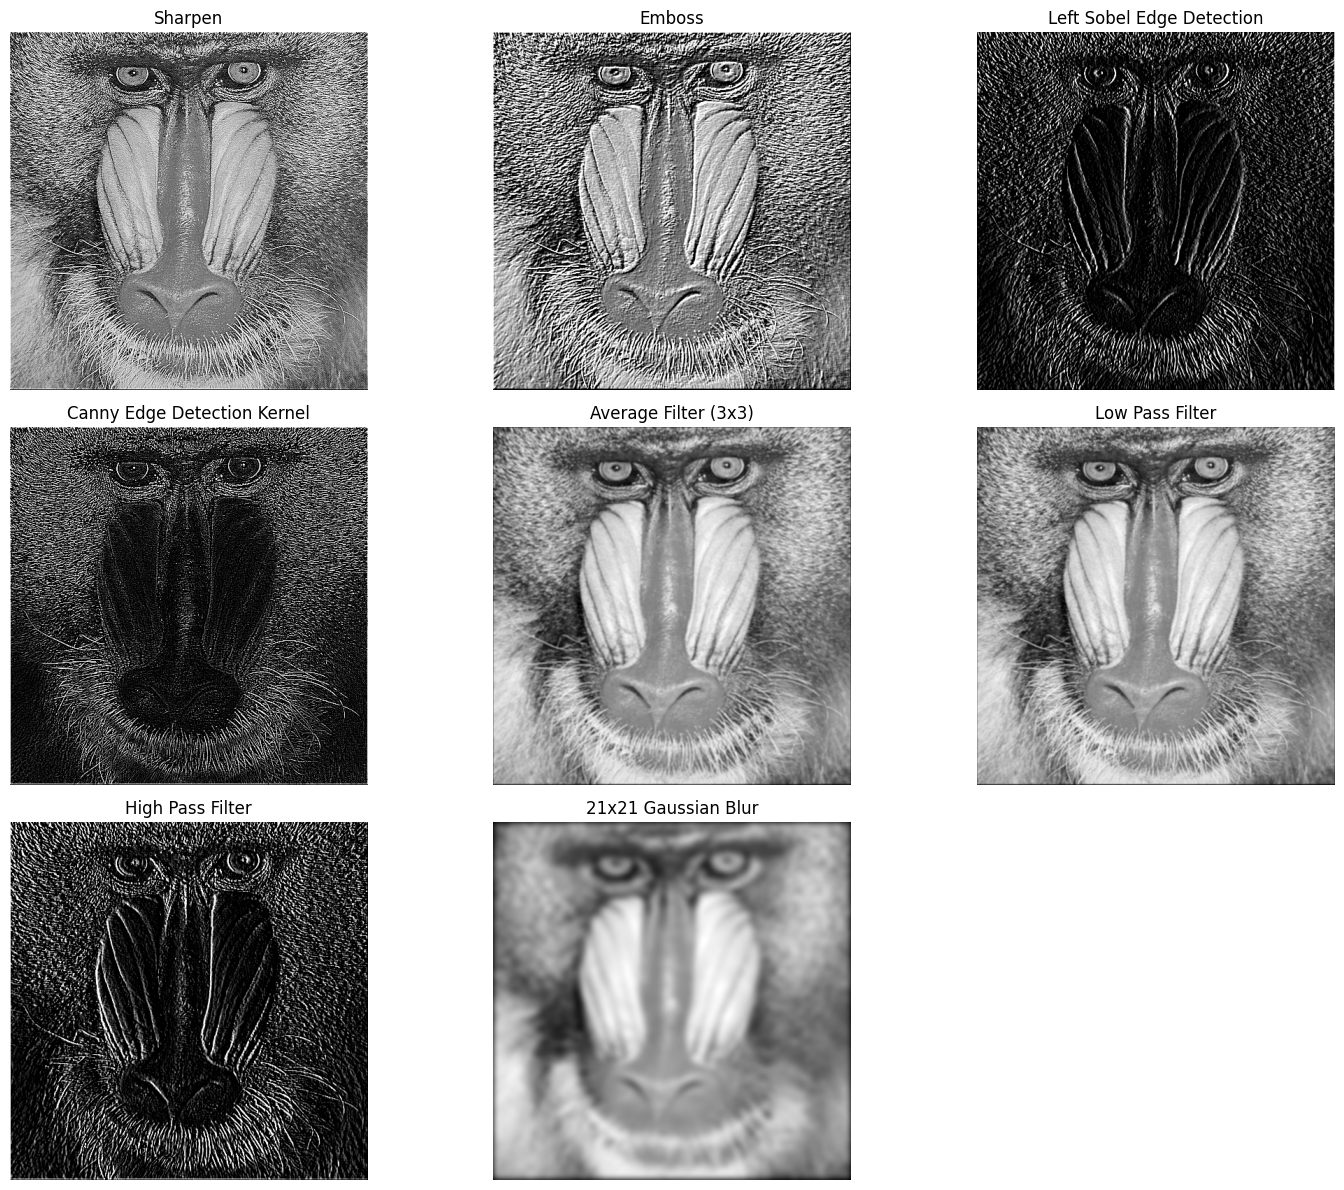

In [5]:
# Load gambar dan ubah ke grayscale
img = cv.imread('/content/drive/MyDrive/SEMESTER 5/Citra/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernels = {
    "Sharpen": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    "Emboss": np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
    "Left Sobel Edge Detection": np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]),
    "Canny Edge Detection Kernel": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    "Average Filter (3x3)": np.ones((3, 3), np.float32) / 9.0,
    "Low Pass Filter": np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]]) / 12.0,
    "High Pass Filter": np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]])
}

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
kernels["21x21 Gaussian Blur"] = gaussian_1d @ gaussian_1d.T

# Jalankan dan Tampilkan Hasil
plt.figure(figsize=(15, 12))
for i, (title, kernel) in enumerate(kernels.items()):
    res = convolution2d(img_gray, kernel, stride=1, padding=kernel.shape[0]//2)
    plt.subplot(3, 3, i+1)
    plt.imshow(res, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


> E. FILTER LIBRARY DAN FILTER MODERN

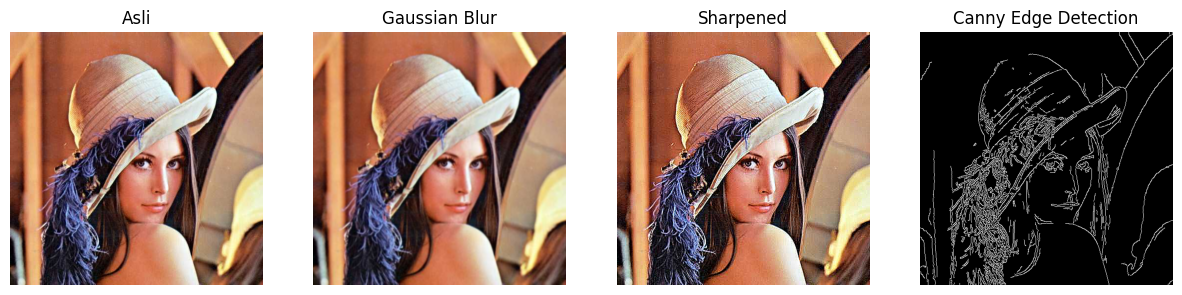

In [6]:
#fungsi tampil berdampingan

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load Gambar Lena
img_lena = cv.imread("/content/drive/MyDrive/SEMESTER 5/Citra/Lena1.jpeg")
if img_lena is None:
    img_lena = img

blur = cv.GaussianBlur(img_lena, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img_lena, -1, sharpen_kernel)

show_side_by_side([img_lena, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2

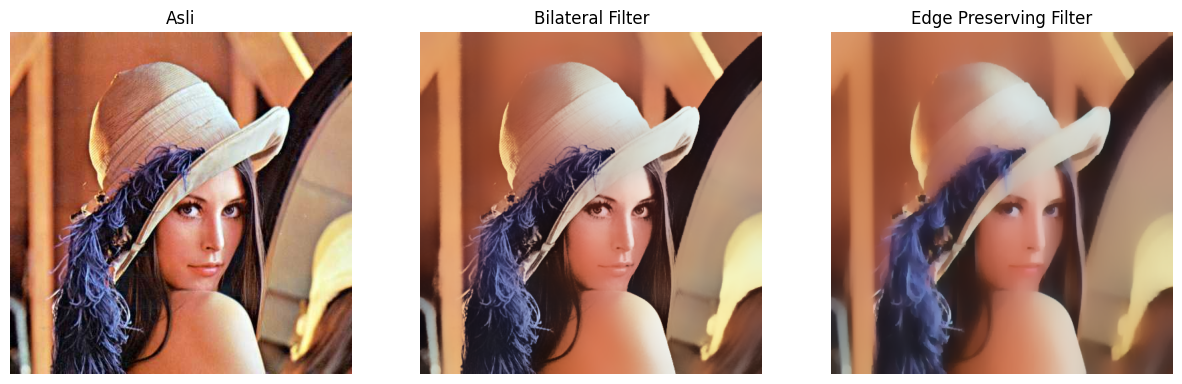

In [7]:
#Filter Modern dari OpenCV
#Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img_lena, 50, 100, 100)

#Edge Preserving Filter (alternatif guided filter)
edge_preserve = cv.edgePreservingFilter(img_lena, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img_lena, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan 3

Kesimpulannya : Bobot kernel (nn.Conv2d) diinisialisasi secara acak (random). Setiap kali kode dijalankan (re-run), filter memicu ekstraksi fitur spasial yang berbeda-beda, seperti pendeteksian tepi horizontal, vertikal, penajaman, atau tekstur tertentu.

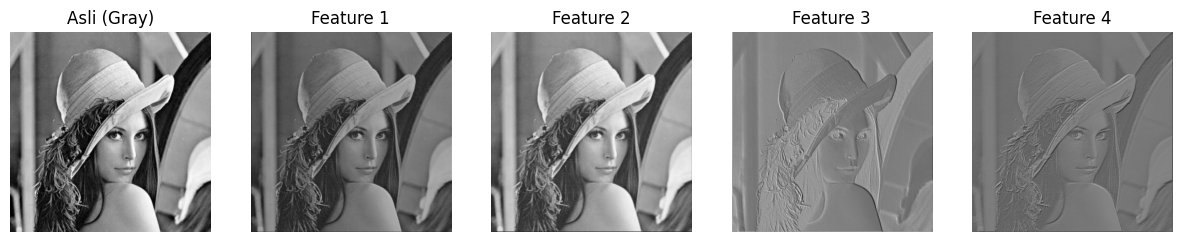

In [9]:
#Filter feature map yg digunakan pd CNN
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

#ubah gambar ke tensor
img_tensor = torch.tensor(img_gray_lena, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

#hasil CNN
with torch.no_grad():
    features = model(img_tensor)
#visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray_lena] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan 4

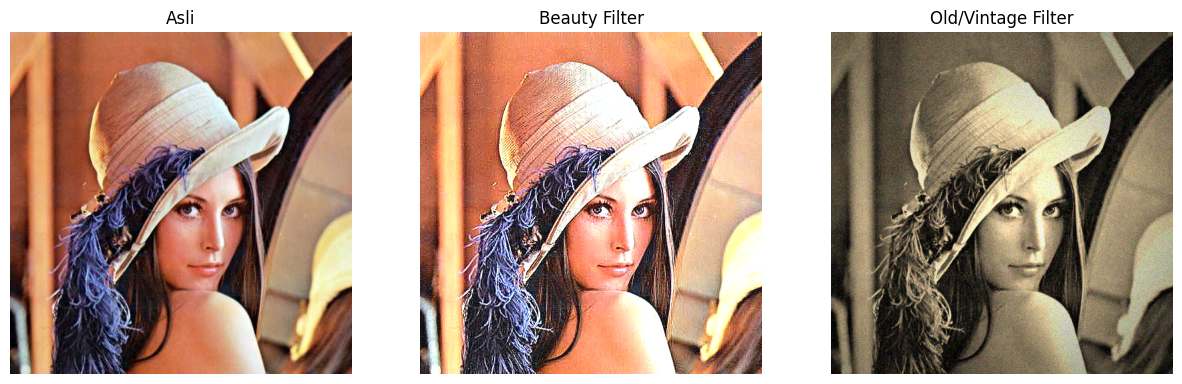

In [10]:
# 1. Beauty Filter
# Step 1: Smoothing kulit dgn bilateral filter
smooth = cv.bilateralFilter(img_lena, d=15, sigmaColor=75, sigmaSpace=75)
# Step 2: Unshrap masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened_b = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
# Step 3: Brightness & contrast
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img_lena, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)
# Step 2: Vignette
rows, cols = img_lena.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel_v = kernel_y * kernel_x.T
mask = kernel_v / kernel_v.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask
#Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
show_side_by_side([img_lena, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

Percobaan 5

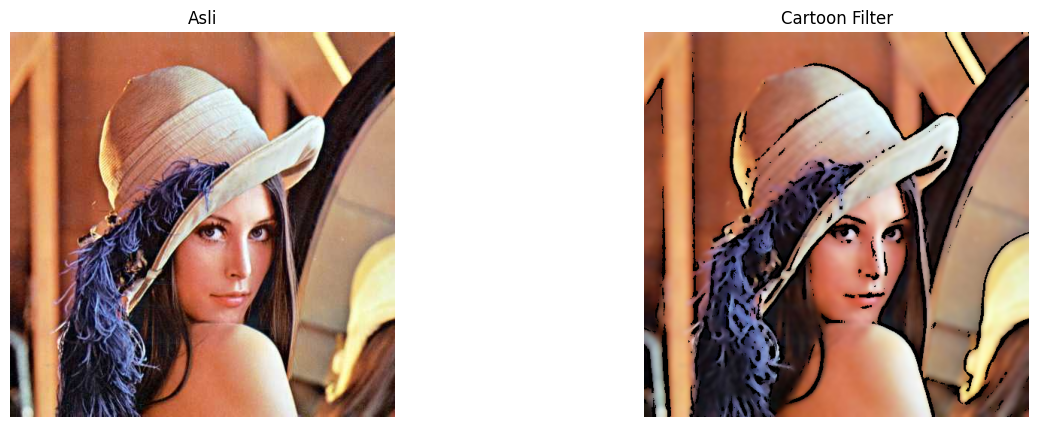

In [11]:
# Filter anime / cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi luas)
gray_c = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray_c, 7)
edges_c = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
# Step 2: Bilateral filter untuk smoothing warna
color_c = cv.bilateralFilter(img_lena, d=9, sigmaColor=200, sigmaSpace=200)
# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color_c, color_c, mask=edges_c)
# Tampilkan
show_side_by_side([img_lena, cartoon], ["Asli", "Cartoon Filter"])

Percobaan 6

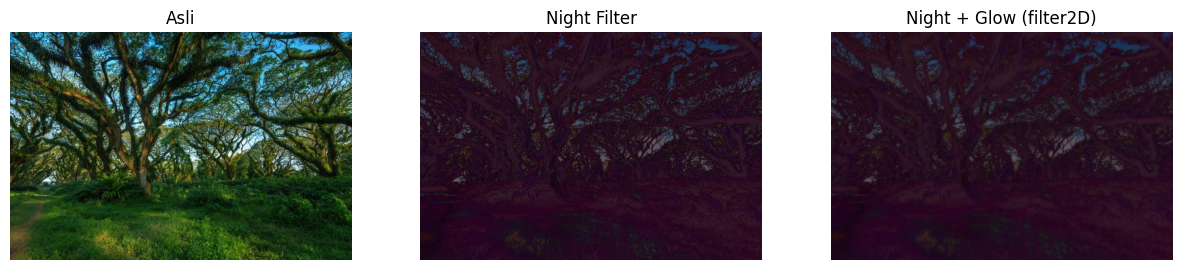

In [13]:
# Percobaan 6: Night Filter
img_d = cv.imread("/content/drive/MyDrive/SEMESTER 5/Citra/djawatan.jpg")
img_gray = cv.cvtColor(img_d, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
# Gunakan img_d (bukan img)
night = cv.convertScaleAbs(img_d, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

# Tampilkan 3 gambar sesuai modul
show_side_by_side([img_d, night, night_glow],
                   ["Asli", "Night Filter", "Night + Glow (filter2D)"])

Percobaan 7

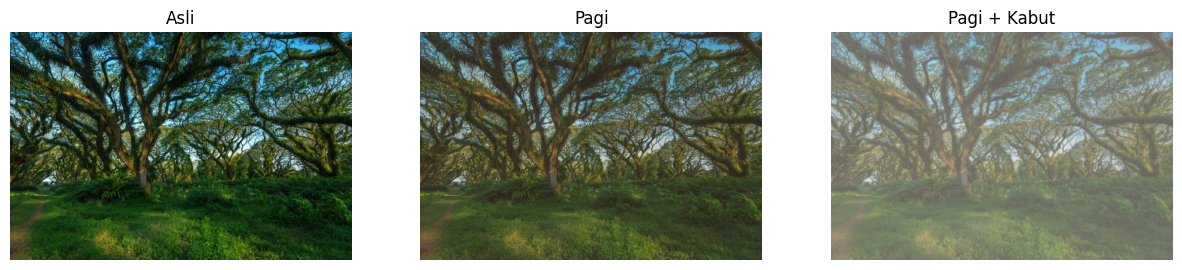

In [15]:
img = cv.imread("/content/drive/MyDrive/SEMESTER 5/Citra/djawatan.jpg")
#Filter Suasana pagi dan Kabut
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                   ["Asli", "Pagi", "Pagi + Kabut"])



> TUGAS PRAKTIKUM

1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”

In [16]:
# a. Tambahkan noise Salt & Pepper pada citra grayscale
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy = np.copy(image)
    # Salt noise (putih)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Pepper noise (hitam)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

noisy_img = add_salt_and_pepper_noise(img_gray, 0.02, 0.02)

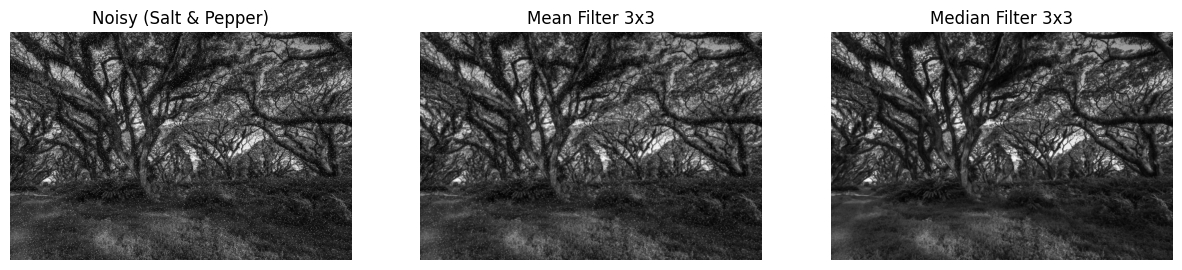

In [17]:
# b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).
mean_filtered = cv.blur(noisy_img, (3, 3))
median_filtered = cv.medianBlur(noisy_img, 3)

# Tampilkan Hasil
show_side_by_side([noisy_img, mean_filtered, median_filtered],
                   ["Noisy (Salt & Pepper)", "Mean Filter 3x3", "Median Filter 3x3"])

c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter.

Jawab :
1.   Mean Filter (Rata-rata): Menghitung nilai rata-rata dari seluruh piksel dalam jendela. Karena nilai atau disertakan dalam perhitungan rata-rata, nilai piksel tetangga yang normal ikut bergeser drastis, sehingga bintik noise tidak hilang melainkan mengabur (blurring) dan meninggalkan bekas noda buram pada citra.
2. Median Filter (Nilai Tengah): Mengurutkan seluruh piksel tetangga lalu memilih nilai tengah (median). Karena piksel noise berada di ujung ekstrem terkecil (0) atau terbesar (255), nilai noise akan tereliminasi saat proses pengurutan dan dipastikan tidak terdefinisi sebagai nilai tengah. Hasilnya, piksel noise digantikan oleh piksel asli tetangganya sehingga citra menjadi bersih tanpa memburamkan garis tepi.



2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

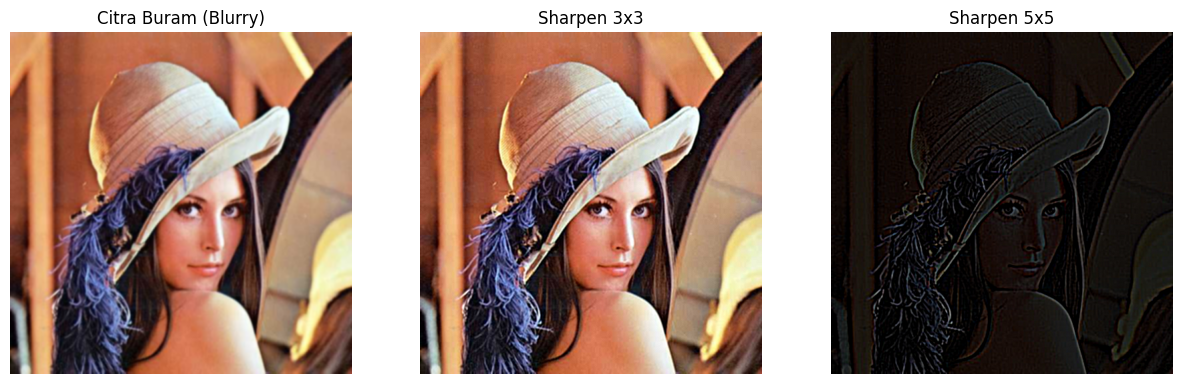

In [22]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()
img_ori = cv.imread('/content/drive/MyDrive/SEMESTER 5/Citra/Lena1.jpeg')
img_gray = cv.cvtColor(img_ori, cv.COLOR_BGR2GRAY)

# a. Membuat kernel penajaman 3x3 dan 5x5
kernel_sharp_3x3 = np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]])

kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, 25, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1]]) / 9.0
# b. Terapkan pada citra yg sedikit buram (blurry)
blurry_img = cv.GaussianBlur(img_ori, (5, 5), 0)
sharp_3x3 = cv.filter2D(blurry_img, -1, kernel_sharp_3x3)
sharp_5x5 = cv.filter2D(blurry_img, -1, kernel_sharp_5x5)

# Tampilkan Hasil Tugas 2
show_side_by_side([blurry_img, sharp_3x3, sharp_5x5],
                   ["Citra Buram (Blurry)", "Sharpen 3x3", "Sharpen 5x5"])

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

1. Kejelasan Tepi (Edge Clarity)
* Kernel 3x3 : Menghasilkan penajaman tepi yang seimbang dan proporsional. Garis-garis batas objek menjadi lebih tegas tanpa mengubah bentuk atau karakteristik asli tepi objek.
* Kernel 5x5: Menghasilkan penajaman yang sangat tinggi (ekstrem/over-sharpening). Tepi objek menjadi terdistorsi dan memunculkan halo effect (garis putih mencolok di sekitar tepi).
2. Kadar Noise / Noise Distortion
* Kernel 3x3: Kadar noise relatif terisolasi dan tidak terlalu tampak mengganggu pada area yang relatif homogen.
* Kernel 5x5: Memperkuat noise dan variasi piksel kecil secara drastis, sehingga menghasilkan tekstur berpasir (grainy noise) yang mengganggu estetika citra.
3. Kernel Optimal untuk Penggunaan Sehari-hari:
Kernel 3x3 adalah pilihan yang paling optimal. Kernel ini meningkatkan kejelasan tepi secara natural tanpa memicu artefak visual atau pembesaran noise berlebih.

3. **Tugas Kreasi: Filter Kartun Sederhana**

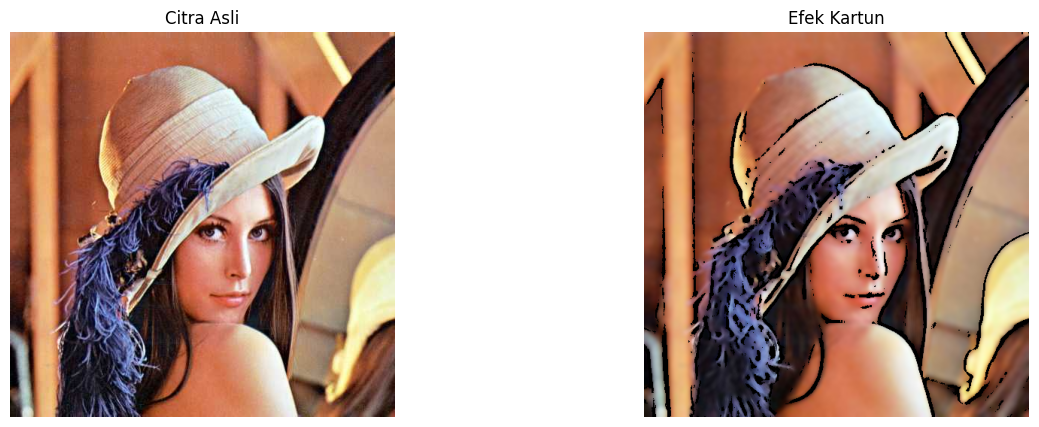

In [23]:
# a. Fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, blockSize=9, C=9)

    # Konversi mask edges (1 channel) ke BGR (3 channel) agar bisa digabung
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan (kombinasi) keduanya menggunakan operasi bitwise AND
    cartoon_img = cv.bitwise_and(color, edges_bgr)
    return cartoon_img

# b. Jalankan dan tampilkan hasil citra asli dan citra efek kartun berdampingan
cartoon_result = kartun(img_ori)

show_side_by_side([img_ori, cartoon_result], ["Citra Asli", "Efek Kartun"])